<a href="https://colab.research.google.com/github/durgesh0187/Analyze-and-Provide-Insights-on-Amazon-Sales-Report/blob/main/Analyze_and_Provide_Insights_on_Amazon_Sales_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 1 – Load Data & Inspect

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime

df = pd.read_csv('/content/sample_data/Amazon Sale Report.csv')

# Step 3: Show first 5 rows
print("First 5 rows of data:")
display(df.head())

# Step 4: Check column names
print("\nColumns in dataset:")
print(df.columns.tolist())


# Step 5: Basic info (data types, missing values)
print("\nDataset Info:")
df.info()

# Step 6: Shape of dataset
print("\nRows and Columns:", df.shape)

# Step 7: Quick stats for numeric columns
print("\nSummary statistics:")
display(df.describe())

First 5 rows of data:


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN



Columns in dataset:
['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel', 'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-nu

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


#Step 2 – Data Cleaning

In [3]:
# Step 1: Normalize column names (remove spaces, lowercase)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Cleaned Column Names:")
print(df.columns.tolist())

# Step 2: Convert date columns to datetime
# (adjust if your dataset has different date column names)
date_cols = ["date", "shipment_date", "delivery_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Step 3: Convert numeric fields
# Example: 'amount' and 'quantity' must be numeric
num_cols = ["amount", "quantity"]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Step 4: Trim whitespace in text columns
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Step 5: Check missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Step 6: Drop rows with no Order ID or Amount (critical info)
if "order_id" in df.columns:
    df = df.dropna(subset=["order_id", "amount"])

print("\nAfter cleaning → Shape of dataset:", df.shape)

Cleaned Column Names:
['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship-service-level', 'category', 'size', 'courier_status', 'qty', 'currency', 'amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'b2b', 'fulfilled-by', 'new', 'pendings']


/tmp/ipython-input-3264693720.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
/tmp/ipython-input-3264693720.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)



Missing Values per Column:
index                      0
order_id                   0
date                       0
status                     0
fulfilment                 0
sales_channel              0
ship-service-level         0
category                   0
size                       0
courier_status             0
qty                        0
currency                7800
amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
b2b                        0
fulfilled-by           89713
new                   128976
pendings              128976
dtype: int64

After cleaning → Shape of dataset: (121176, 21)


#Step 3 – Sales Overview

------ Sales Overview ------
Total Revenue       : ₹78,590,170.25
Total Orders        : 112887
Average Order Value : ₹696.18


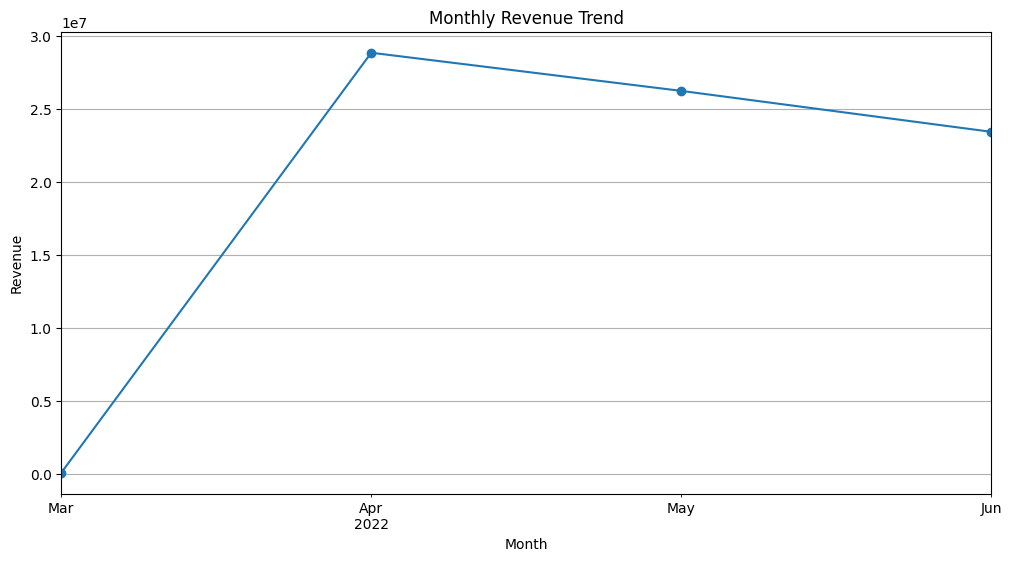

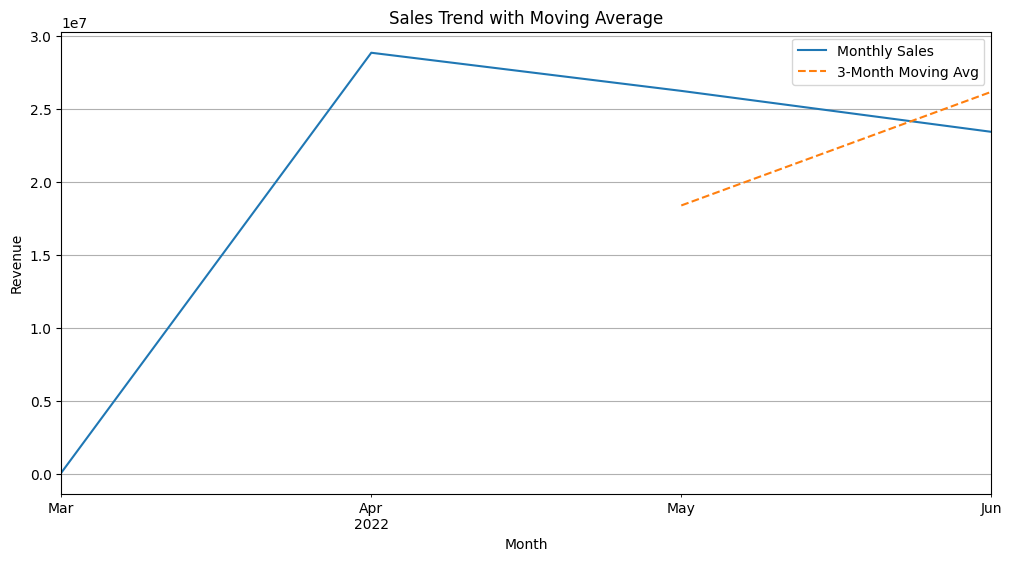

In [4]:
# Step 1: Key Sales Metrics
total_revenue = df["amount"].sum()
total_orders = df["order_id"].nunique() if "order_id" in df.columns else df.shape[0]
total_items = df["quantity"].sum() if "quantity" in df.columns else None
avg_order_value = total_revenue / total_orders

print("------ Sales Overview ------")
print(f"Total Revenue       : ₹{total_revenue:,.2f}")
print(f"Total Orders        : {total_orders}")
if total_items is not None:
    print(f"Total Items Sold    : {total_items}")
print(f"Average Order Value : ₹{avg_order_value:,.2f}")

# Step 2: Monthly Sales Trend
if "date" in df.columns:
    df["month"] = df["date"].dt.to_period("M")
    monthly_sales = df.groupby("month")["amount"].sum()

    plt.figure(figsize=(12,6))
    monthly_sales.plot(kind="line", marker="o")
    plt.title("Monthly Revenue Trend")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.grid(True)
    plt.show()

# Step 3: Moving Average (3-month rolling)
if "date" in df.columns:
    rolling_avg = monthly_sales.rolling(window=3).mean()

    plt.figure(figsize=(12,6))
    monthly_sales.plot(label="Monthly Sales")
    rolling_avg.plot(label="3-Month Moving Avg", linestyle="--")
    plt.title("Sales Trend with Moving Average")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.legend()
    plt.grid(True)
    plt.show()

#Step 4 – Product Analysis

Category-wise Sales:


,amount,order_id
category,,
T-shirt,39206756.65,44678
Shirt,21297770.08,43527
Blazzer,11215104.12,14207
Trousers,5346286.30,9699
Perfume,789419.66,1082
Wallet,458408.18,853
Socks,150757.50,391
Shoes,124752.76,135
Watch,915.00,2


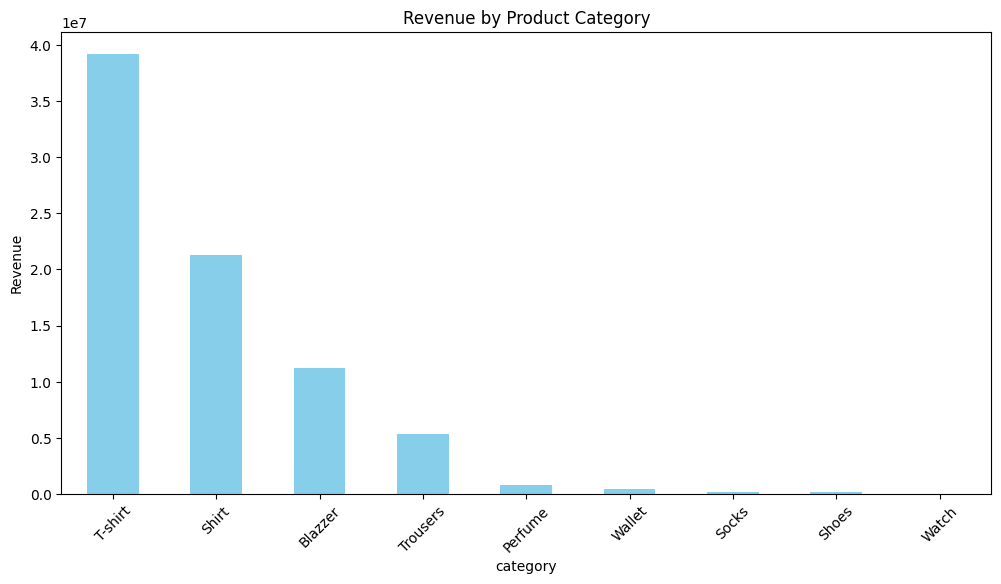

from matplotlib import pyplot as plt
category_sales['amount'].plot(kind='hist', bins=20, title='amount')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
category_sales['order_id'].plot(kind='hist', bins=20, title='order_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
category_sales.plot(kind='scatter', x='amount', y='order_id', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
category_sales['amount'].plot(kind='line', figsize=(8, 4), title='amount')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
category_sales['order_id'].plot(kind='line', figsize=(8, 4), title='order_id')
plt.gca().spines[['top', 'right']].set_visible(False)

In [6]:
# Step 1: Sales by Product Category
if "category" in df.columns:
    agg_dict = {"amount": "sum"}
    if "quantity" in df.columns:
        agg_dict["quantity"] = "sum"
    if "order_id" in df.columns:
        agg_dict["order_id"] = "nunique"

    category_sales = df.groupby("category").agg(agg_dict).sort_values(by="amount", ascending=False)

    print("Category-wise Sales:")
    display(category_sales)

    # Visualization
    category_sales["amount"].plot(kind="bar", figsize=(12,6), color="skyblue")
    plt.title("Revenue by Product Category")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.show()

# Step 2: Top 10 Products
if "product_name" in df.columns:
    agg_dict = {"amount": "sum"}
    if "quantity" in df.columns:
        agg_dict["quantity"] = "sum"

    top_products = df.groupby("product_name").agg(agg_dict).sort_values(by="amount", ascending=False).head(10)

    print("\nTop 10 Products by Revenue:")
    display(top_products)

    top_products["amount"].plot(kind="barh", figsize=(10,6), color="orange")
    plt.title("Top 10 Products by Revenue")
    plt.xlabel("Revenue")
    plt.show()

# Step 3: Price Distribution (only if quantity exists)
if "amount" in df.columns and "quantity" in df.columns:
    df["unit_price"] = df["amount"] / df["quantity"]

    plt.figure(figsize=(10,5))
    plt.hist(df["unit_price"], bins=50, color="purple", alpha=0.7)
    plt.title("Distribution of Product Prices")
    plt.xlabel("Price per Unit")
    plt.ylabel("Frequency")
    plt.show()

# Step 4: Slow Movers
if "product_name" in df.columns:
    slow_products = df.groupby("product_name")["amount"].sum().sort_values().head(10)
    print("\nBottom 10 Products (Slow Movers):")
    display(slow_products)


#Step 5 – Fulfillment Analysis

In [17]:
# Fulfillment Analysis
if "Fulfilment" in df.columns:
    fulfillment_summary = df.groupby("Fulfilment").agg(
        revenue=("Amount", "sum"),
        orders=("Order ID", "nunique")
    ).reset_index()

    print("📦 Fulfillment Summary:")
    display(fulfillment_summary)

    # Plot
    fulfillment_summary.set_index("Fulfilment")["revenue"].plot(
        kind="bar", figsize=(8,5), color="skyblue"
    )
    plt.title("Revenue by Fulfilment Type")
    plt.ylabel("Revenue")
    plt.show()

# Courier Status Analysis
if "Courier Status" in df.columns:
    courier_summary = df.groupby("Courier Status").agg(
        revenue=("Amount", "sum"),
        orders=("Order ID", "nunique")
    ).reset_index()

    print("\n📦 Courier Status Summary:")
    display(courier_summary)

    # Plot
    courier_summary.set_index("Courier Status")["revenue"].plot(
        kind="bar", figsize=(8,5), color="orange"
    )
    plt.title("Revenue by Courier Status")
    plt.ylabel("Revenue")
    plt.show()


#Step 6 – Geographical Analysis

In [26]:
# Strip spaces and normalize all column names
df.columns = df.columns.str.strip()  # remove leading/trailing spaces
df.columns = df.columns.str.replace(' ', '_', regex=True)  # replace spaces with underscores
df.columns = df.columns.str.replace('-', '_', regex=True)  # replace hyphens with underscores
df.columns = df.columns.str.lower()  # convert all to lowercase

print("Cleaned columns:")
print(df.columns.tolist())


Cleaned columns:
['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel', 'ship_service_level', 'category', 'size', 'courier_status', 'qty', 'currency', 'amount', 'ship_city', 'ship_state', 'ship_postal_code', 'ship_country', 'b2b', 'fulfilled_by', 'new', 'pendings', 'month']



📍 Top 10 Revenue by ship_state:


,revenue,orders
ship_state,,
MAHARASHTRA,13340333.05,19648
KARNATAKA,10480694.22,15274
TELANGANA,6915018.08,9748
UTTAR PRADESH,6823947.08,9390
TAMIL NADU,6519182.30,9883
DELHI,4232738.97,5984
KERALA,3823559.58,5699
WEST BENGAL,3507212.82,5251
ANDHRA PRADESH,3217859.86,4632


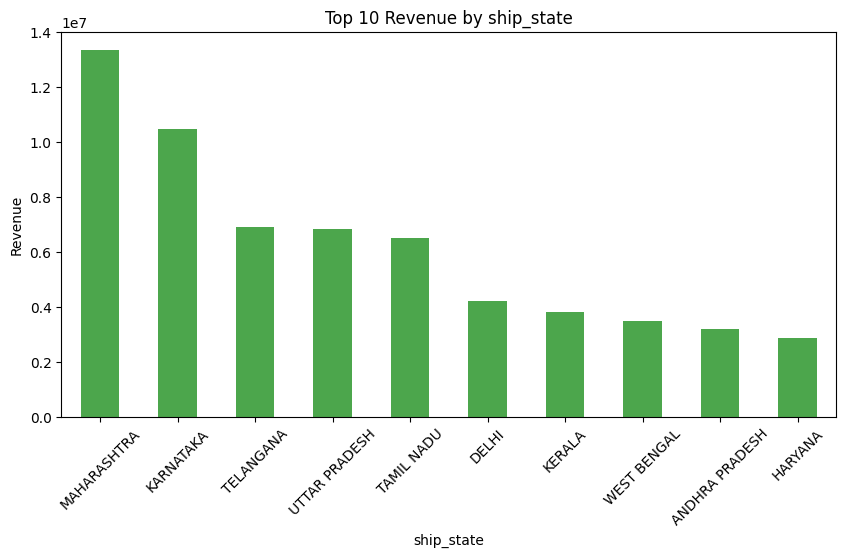


📍 Top 10 Revenue by ship_city:


,revenue,orders
ship_city,,
BENGALURU,6845390.65,9934
HYDERABAD,4946394.25,6967
MUMBAI,3701843.04,5416
NEW DELHI,3612512.78,5102
CHENNAI,3103415.74,4667
PUNE,2342011.18,3403
KOLKATA,1413603.87,2116
GURUGRAM,1220562.74,1690
THANE,1004503.29,1522


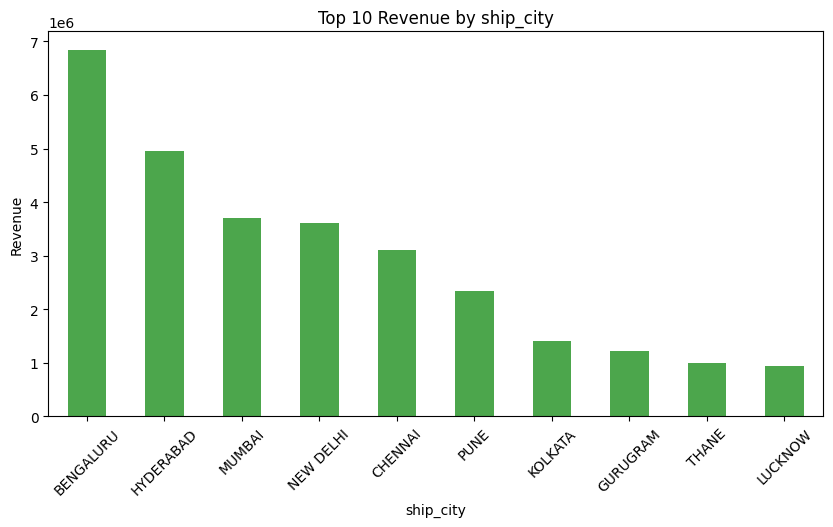

In [27]:
import matplotlib.pyplot as plt

geo_cols = ["ship_state", "ship_city"]

for col in geo_cols:
    if col in df.columns:
        geo_sales = df.groupby(col).agg(
            revenue=("amount", "sum"),
            orders=("order_id", "nunique")
        ).sort_values("revenue", ascending=False)

        print(f"\n📍 Top 10 Revenue by {col}:")
        display(geo_sales.head(10))

        # Plot top 10
        geo_sales["revenue"].head(10).plot(
            kind="bar", figsize=(10,5), color="green", alpha=0.7
        )
        plt.title(f"Top 10 Revenue by {col}")
        plt.ylabel("Revenue")
        plt.xticks(rotation=45)
        plt.show()
    else:
        print(f"⚠️ Column '{col}' not found. Skipping {col} analysis.")


#Step 7 – Returns & Cancellations Analysis


📊 Orders by Status:


,status,count,percentage
0,Shipped,77607,64.044860
1,Shipped - Delivered to Buyer,28748,23.724170
2,Cancelled,10763,8.882122
3,Shipped - Returned to Seller,1951,1.610055
4,Shipped - Picked Up,973,0.802964
5,Pending,656,0.541361
6,Pending - Waiting for Pick Up,281,0.231894
7,Shipped - Returning to Seller,145,0.119661
8,Shipped - Out for Delivery,35,0.028884
9,Shipped - Rejected by Buyer,11,0.009078


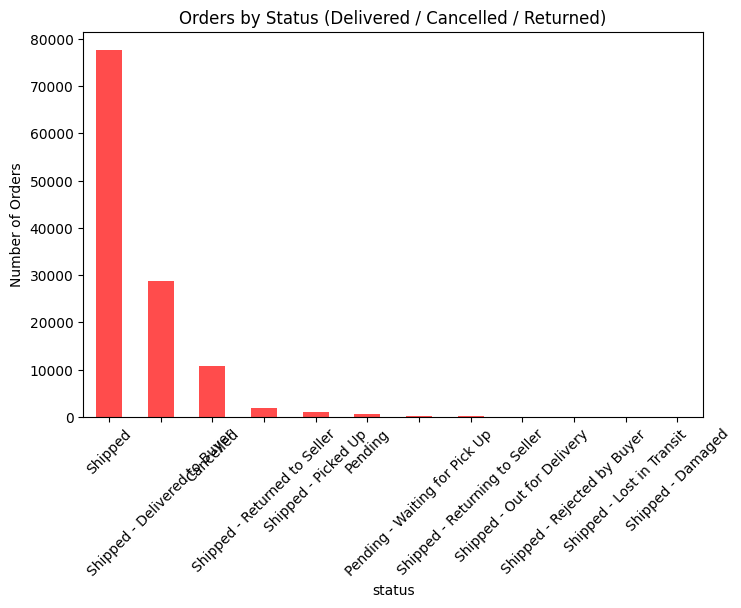

In [28]:
# Returns & Cancellations Analysis
if "status" in df.columns:
    status_summary = df["status"].value_counts().reset_index()
    status_summary.columns = ["status", "count"]
    total_orders = status_summary["count"].sum()
    status_summary["percentage"] = (status_summary["count"] / total_orders) * 100

    print("\n📊 Orders by Status:")
    display(status_summary)

    # Plot
    status_summary.set_index("status")["count"].plot(
        kind="bar", figsize=(8,5), color="red", alpha=0.7
    )
    plt.title("Orders by Status (Delivered / Cancelled / Returned)")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("⚠️ 'status' column not found. Skipping Returns & Cancellations analysis.")


#Step 8 – Actionable Recommendations

In [29]:
recommendations = []

# 1️⃣ Product Insights
if "category" in df.columns:
    top_category = df.groupby("category")["amount"].sum().idxmax()
    low_category = df.groupby("category")["amount"].sum().idxmin()
    recommendations.append(f"🔹 Focus on top-selling category: {top_category}. Consider promotions or bundles.")
    recommendations.append(f"🔹 Low-performing category: {low_category}. Review inventory or consider delisting.")

# 2️⃣ Fulfillment Insights
if "fulfilment" in df.columns:
    top_fulfillment = df.groupby("fulfilment")["amount"].sum().idxmax()
    recommendations.append(f"📦 Most revenue comes from fulfillment type: {top_fulfillment}. Ensure smooth operations here.")

# 3️⃣ Geography Insights
geo_cols = ["ship_state", "ship_city"]
for col in geo_cols:
    if col in df.columns:
        top_geo = df.groupby(col)["amount"].sum().idxmax()
        recommendations.append(f"📍 Highest revenue comes from {col}: {top_geo}. Consider targeted marketing and stocking.")

# 4️⃣ Returns / Cancellations
if "status" in df.columns:
    cancelled_pct = (df['status'].str.contains('Cancelled', case=False).sum() / len(df)) * 100
    recommendations.append(f"⚠️ Cancellation rate: {cancelled_pct:.2f}%. Investigate high-cancellation products or process issues.")

# 5️⃣ General
recommendations.append("💡 Monitor slow-moving products, optimize inventory, and focus on best-selling items.")
recommendations.append("💡 Consider promotions in top revenue regions and improve delivery speed for customer satisfaction.")

# Display Recommendations
print("📝 Actionable Recommendations:\n")
for rec in recommendations:
    print(rec)



📝 Actionable Recommendations:

🔹 Focus on top-selling category: T-shirt. Consider promotions or bundles.
🔹 Low-performing category: Watch. Review inventory or consider delisting.
📦 Most revenue comes from fulfillment type: Amazon. Ensure smooth operations here.
📍 Highest revenue comes from ship_state: MAHARASHTRA. Consider targeted marketing and stocking.
📍 Highest revenue comes from ship_city: BENGALURU. Consider targeted marketing and stocking.
⚠️ Cancellation rate: 8.88%. Investigate high-cancellation products or process issues.
💡 Monitor slow-moving products, optimize inventory, and focus on best-selling items.
💡 Consider promotions in top revenue regions and improve delivery speed for customer satisfaction.
